In [206]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path

from sklearn.metrics import (
accuracy_score, precision_score, recall_score,
f1_score, classification_report, confusion_matrix
)

In [207]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f'TensorFlow version : {tf.__version__}')
print(f'Random seed set to : {SEED}')

TensorFlow version : 2.20.0
Random seed set to : 42


In [208]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 50
LR = 1e-3

STEP 3: Results directory

In [209]:
results_dir = "results/assignment/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

STEP 4: Check for GPU Availability

In [210]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'\nGPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('\nNo GPU found — training will run on CPU (slower).')


GPUs available: 2
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
 - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')


load dataset

In [211]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)
inner_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"
print(os.listdir(inner_path))

Path to dataset files: /kaggle/input/datasets/emmarex/plantdisease
['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


Filter out the folders required


In [212]:
import shutil

source_base = inner_path  # wherever the class folders actually are
filtered_dir = "/kaggle/working/tomato_filtered"

if os.path.exists(filtered_dir):
    shutil.rmtree(filtered_dir)
os.makedirs(filtered_dir, exist_ok=True)

classes_needed = ["Tomato_healthy", "Tomato__Tomato_mosaic_virus"]
try:
    for cls in classes_needed:
        src = os.path.join(source_base, cls)
        dst = os.path.join(filtered_dir, cls)
        shutil.copytree(src, dst)
except FileExistsError:
    print("Filtered dataset ready at:", filtered_dir)
    print(os.listdir(filtered_dir))

Step: Install split-folders and split into train/val/test

In [213]:
!pip install split-folders --quiet

import splitfolders

base_output = "/kaggle/working/tomato_split"

splitfolders.ratio(
    "/kaggle/working/tomato_filtered",
    output=base_output,
    seed=SEED,
    ratio=(.7, .15, .15)
)

print("Split complete!")

Copying files: 1964 files [00:00, 4964.33 files/s]

Split complete!


Confirm the split

In [214]:
from pathlib import Path

BASE_DIR = Path(base_output)
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'

for split, d in [('train', train_dir), ('val', val_dir), ('test', test_dir)]:
    exists = d.exists()
    count = sum(1 for _ in d.rglob('*.JPG')) + sum(1 for _ in d.rglob('*.jpg'))
    print(f'{split:>5} dir exists={exists} images≈{count}')

train dir exists=True images≈1374
  val dir exists=True images≈293
 test dir exists=True images≈297


Load datasets with binary label mode

In [215]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=True,
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)

class_names = train_dataset.class_names
print(f'Classes: {class_names}')

Found 1374 files belonging to 2 classes.
Found 293 files belonging to 2 classes.
Found 297 files belonging to 2 classes.
Classes: ['Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


STEP 13: Get class names and number of classes.

In [216]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (2): ['Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [217]:
for idx, name in enumerate(class_names):
    print(idx, name)

0 Tomato__Tomato_mosaic_virus
1 Tomato_healthy


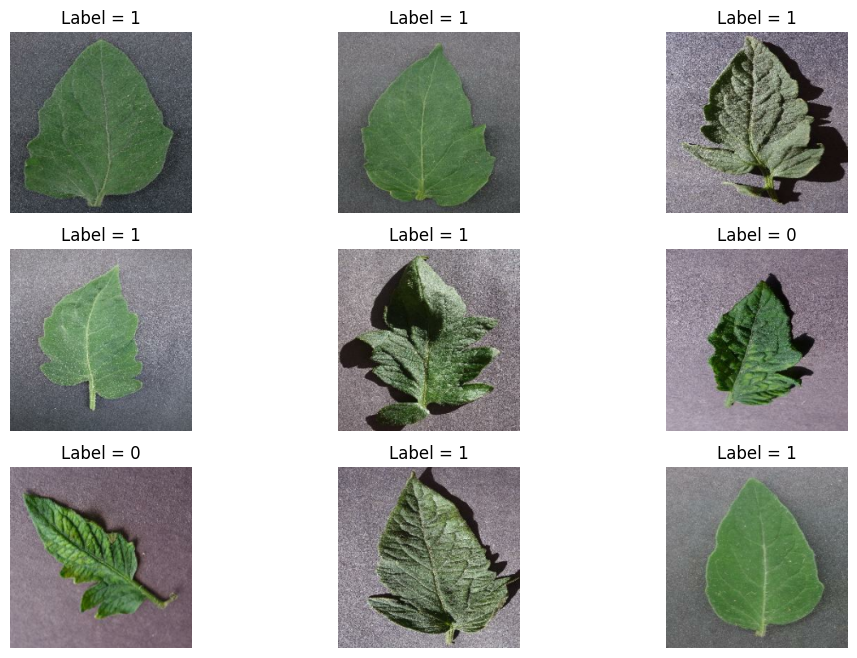

In [218]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_dataset))

plt.figure(figsize=(12,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(f"Label = {labels[i].numpy()}")
    plt.axis("off")
plt.show()

STEP 14: Sanity-Check (visualise dataset samples).

In [219]:
# Capture one fixed batch so the visualisation is stable across re-runs
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

STEP 15: Visualise the first 16 images and their labels

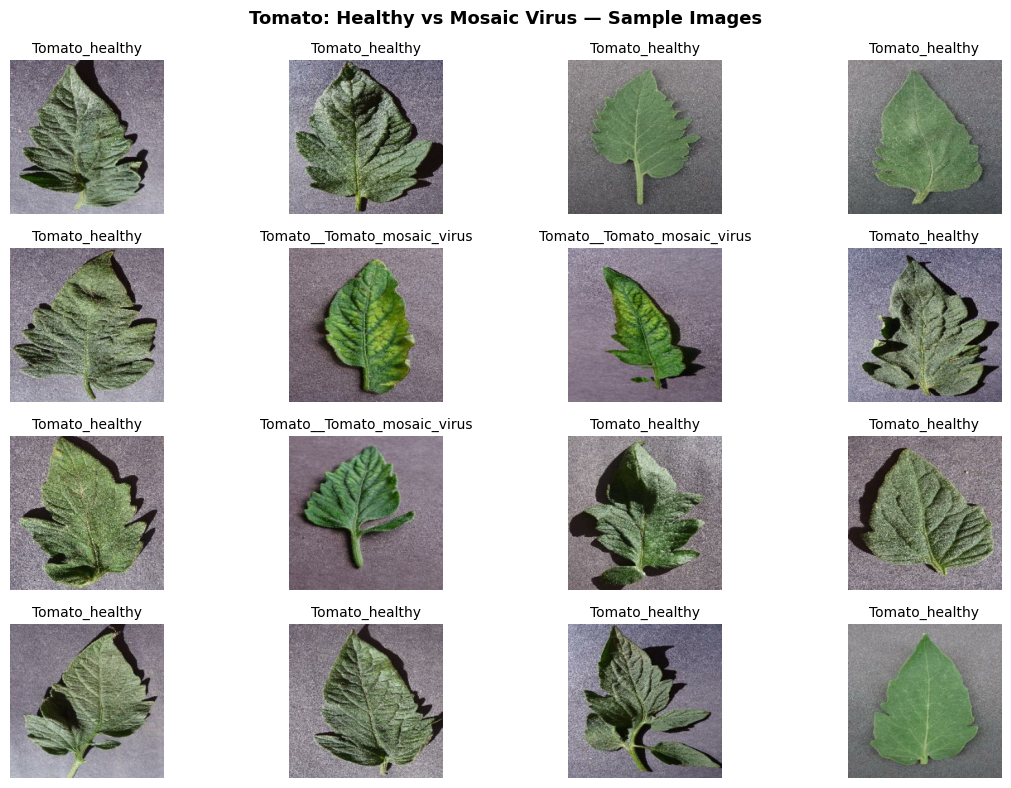

In [220]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    label_val = fixed_labels[i]
    label_idx = int(label_val[0]) if hasattr(label_val, '__len__') else int(label_val)
    plt.title(class_names[label_idx], fontsize=10)
    plt.axis('off')
plt.suptitle('Tomato: Healthy vs Mosaic Virus — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lab8_samples.png', dpi=120, bbox_inches='tight')
plt.show()

STEP 16: Optimise the data pipeline.

In [221]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = (train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE))

valid_dataset = (val_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))
print('Pipeline optimised with cache + shuffle + prefetch.')

Pipeline optimised with cache + shuffle + prefetch.


STEP 17: Define the data augmentation pipeline.

In [222]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

STEP 18: Visualise augmentation effects on one image

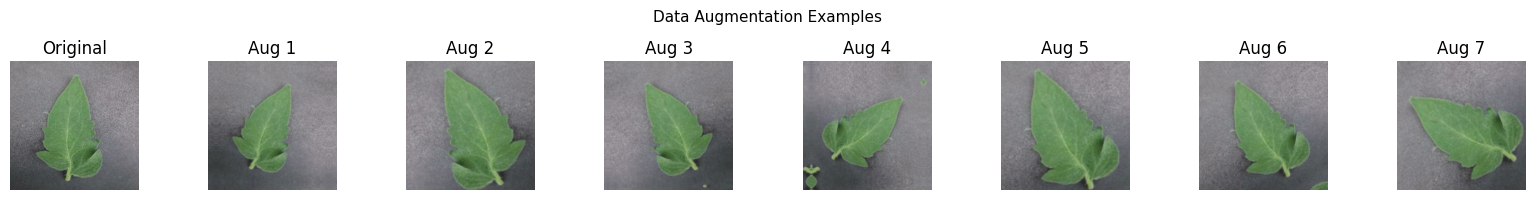

In [223]:
for images, _ in train_dataset.take(1):
    sample = images[0:1] # shape (1, 224, 224, 3)
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')


plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig('lab8_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

STEP 19: Define shared callbacks and utilities.

In [224]:
os.makedirs('models', exist_ok=True)
def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'models/{name}_best.keras',
            monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=8,
            restore_best_weights=True, verbose=1,),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=4, min_lr=1e-7, verbose=1),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()   # <-- was missing


def evaluate_model(model, dataset, class_names, title='Model', results_dir='./'):
    """Evaluate a BINARY classification model (sigmoid output, threshold 0.5)."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # preds = (probs >= 0.5).astype(int).flatten()
        preds = np.argmax(probs, axis=1) 
        y_prob.append(probs.flatten())
        y_pred.append(preds)
        y_true.append(labels.numpy().flatten())

    y_true = np.concatenate(y_true).astype(int)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f"\n{title}")
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall   : {recall_score(y_true, y_pred):.4f}')
    print(f'F1-Score : {f1_score(y_true, y_pred):.4f}')

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, cmap='Blues', cbar=False, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(results_dir + f'{title.lower().replace(" ", "_")}_confusion.png',
                dpi=120, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)

STEP 20: Build the Custom CNN Architecture

In [225]:
# INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
# OUTPUTS = num_classes

# def build_custom_cnn(input_shape, augmentation):
#     """
#     A three-block CNN built entirely from scratch.
#     Filters double each block (32 >> 64 >> 128) following a standard design
#     pattern.
#     Augmentation is embedded inside the model so it runs automatically during
#     training.
#     """
#     inputs = tf.keras.Input(shape=input_shape)
    
#     # Augmentation (active only during training)
#     x = augmentation(inputs)
#     # Normalise pixel values from [0, 255] to [0, 1]
#     x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    
#     # Block 1: 32 filters
#     x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
#     x = tf.keras.layers.BatchNormalization()(x)
#     x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
#     x = tf.keras.layers.BatchNormalization()(x)
#     x = tf.keras.layers.MaxPooling2D()(x)
#     x = tf.keras.layers.Dropout(0.25)(x)
    
#     # Block 2: 64 filters
#     x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
#     x = tf.keras.layers.BatchNormalization()(x)
#     x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
#     x = tf.keras.layers.BatchNormalization()(x)
#     x = tf.keras.layers.MaxPooling2D()(x)
#     x = tf.keras.layers.Dropout(0.25)(x)
    
#     # Block 3: 128 filters
#     x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
#     x = tf.keras.layers.BatchNormalization()(x)
#     x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
#     x = tf.keras.layers.BatchNormalization()(x)
#     x = tf.keras.layers.MaxPooling2D()(x)
#     x = tf.keras.layers.Dropout(0.25)(x)
    
#     # Classification Head
#     x = tf.keras.layers.GlobalAveragePooling2D()(x)
#     x = tf.keras.layers.Dense(256, activation='relu')(x)
#     x = tf.keras.layers.Dropout(0.5)(x)
    
#     # Binary output: sigmoid → probability of class 1 (dogs)
#     outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)
#     return tf.keras.Model(inputs, outputs, name='custom_cnn')
    
# cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
# cnn_model.summary()

STEP 21: Compile the custom CNN mdel.

In [226]:
# cnn_model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),  # slightly lower LR
#     loss='binary_crossentropy',
#     metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),
#              tf.keras.metrics.Recall(name='recall')]
# )

In [227]:
print(val_dataset.cardinality().numpy())
for images, labels in val_dataset:
    print(images.shape)

10
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(32, 224, 224, 3)
(5, 224, 224, 3)


In [228]:
import os
print("Healthy:", len(os.listdir("/kaggle/working/tomato_filtered/Tomato_healthy")))
print("Mosaic virus:", len(os.listdir("/kaggle/working/tomato_filtered/Tomato__Tomato_mosaic_virus")))

Healthy: 1591
Mosaic virus: 373


STEP 22: Train the model and save the training history for later visualisation.

In [229]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

y_train = np.concatenate([labels.numpy().flatten() for _, labels in train_dataset])
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(class_weight_dict)

{0: np.float64(2.632183908045977), 1: np.float64(0.6172506738544474)}


In [230]:
# # cnn_history = cnn_model.fit(
# #     train_dataset, validation_data=valid_dataset,epochs=EPOCHS,
# #     callbacks=make_callbacks('custom_cnn'), verbose=1)

# cnn_history = cnn_model.fit(
#     train_dataset, validation_data=val_dataset,
#     epochs=EPOCHS, callbacks=make_callbacks('custom_cnn_v2'),
#     class_weight=class_weight_dict,
#     verbose=1
# )

STEP 23: Evaluate the Custom CNN using loss and accuracy on the validation set

In [231]:
# # cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
# # print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
# # print(f'val_accuracy: {cnn_val_acc:.4f}')

# results = cnn_model.evaluate(val_dataset, verbose=0)
# cnn_val_loss, cnn_val_acc, cnn_val_precision, cnn_val_recall = results

# print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
# print(f'val_accuracy: {cnn_val_acc:.4f}')
# print(f'val_precision: {cnn_val_precision:.4f}')
# print(f'val_recall: {cnn_val_recall:.4f}')

**STEP 24: Visualise the Learning curves**

In [232]:
# plot_learning_curves(cnn_history, 'Custom CNN')

**STEP 25: Evaluate the custom CNN model on the test data**

In [233]:
# cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')

**STEP 26: Build the Transfer Learning Model (MobileNetV3Small)**

In [234]:
def build_transfer_model(input_shape, augmentation, backbone='mobilenetv3small'):
    """
    Feature extraction model:
    1. Augment input (training only)
    2. Preprocess for MobileNetV3 (scales to [-1, 1])
    3. Frozen MobileNetV3Small backbone (no top)
    4. GlobalAveragePooling2D
    5. Dense classification head
    """
    if backbone == 'mobilenetv3small':
        base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name = 'mobilenetv3small_transfer'
    
    else:
    
        # Fallback: MobileNetV2
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name = 'mobilenetv2_transfer'
    
    # Freeze all base layers for feature extraction (no training)
    base_model.trainable = False
    print(f'Base model : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')
    
    # Build the model graph
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x) # scale pixels to [-1, 1]
    x = base_model(x, training=False)
    # frozen inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(2, activation='softmax')(x)
    
    return tf.keras.Model(inputs, outputs, name=model_name), base_model
tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation, backbone='mobilenetv3small')

Base model : MobileNetV3Small
Trainable layers: 0 / 157


STEP 27: Compile and train the model

In [235]:
# from sklearn.utils.class_weight import compute_class_weight
# import numpy as np

# classes = np.unique(train_labels)

# weights = compute_class_weight(
#     class_weight="balanced",
#     classes=classes,
#     y=train_labels
# )

# class_weights = dict(zip(classes, weights))
# print(class_weights)

In [236]:



TL_LR = 1e-4
# Lower LR for transfer learning head
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

tl_history = tl_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    # class_weight=class_weights,
    callbacks=make_callbacks('tl_feature_extraction'),
    verbose=1,
)

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.7067 - loss: 0.6182 - val_accuracy: 0.8157 - val_loss: 0.4093 - learning_rate: 1.0000e-04
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8755 - loss: 0.3196 - val_accuracy: 0.8976 - val_loss: 0.2380 - learning_rate: 1.0000e-04
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9440 - loss: 0.1925 - val_accuracy: 0.9454 - val_loss: 0.1535 - learning_rate: 1.0000e-04
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9702 - loss: 0.1301 - val_accuracy: 0.9727 - val_loss: 0.1089 - learning_rate: 1.0000e-04
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9803 - loss: 0.0991 - val_accuracy: 0.9932 - val_loss: 0.0820 - learning_rate: 1.0000e-04
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9884 - loss: 0.0690 - val_accuracy: 0.9932 - val_loss: 0.0710 - learning_rate: 1.0000e-04
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9913 

STEP 28: Evaluate the Transfer Learning Model

MobileNetV3 TL -> val_loss: 0.0126
MobileNetV3 TL -> val_accuracy: 0.9966


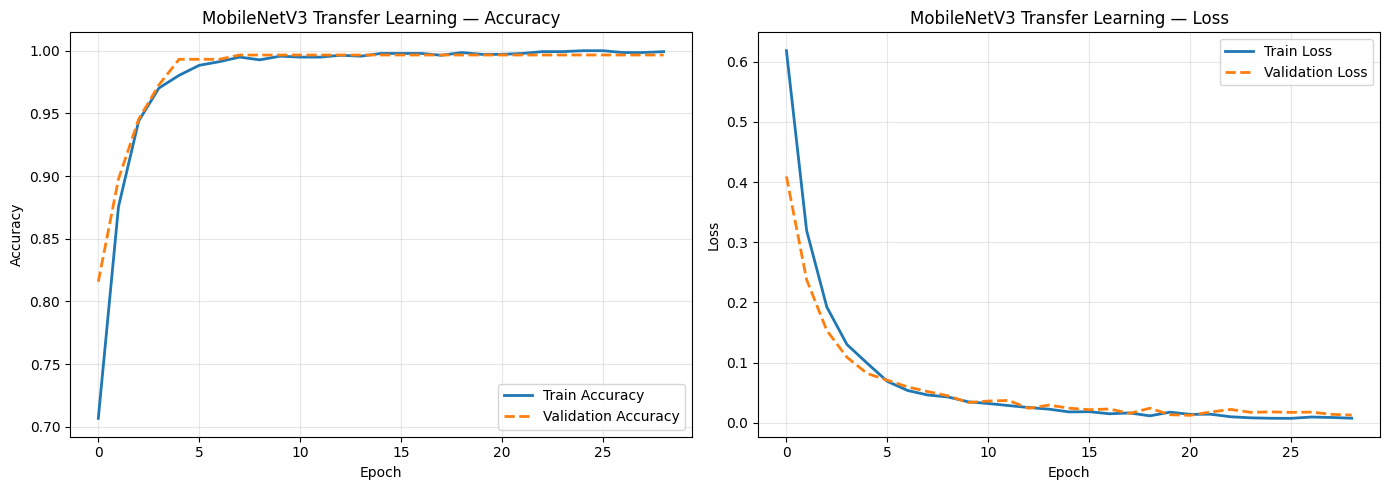

In [237]:
tl_val_loss, tl_val_acc = tl_model.evaluate(valid_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

STEP 29: Evaluate the Transfer Learning Model on the test set

In [238]:
print(tl_model.output_shape)

(None, 2)


2026-07-29 00:56:48.544495: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



MobileNetV3 Transfer
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Classification Report:
                             precision    recall  f1-score   support

Tomato__Tomato_mosaic_virus     1.0000    1.0000    1.0000        57
             Tomato_healthy     1.0000    1.0000    1.0000       240

                   accuracy                         1.0000       297
                  macro avg     1.0000    1.0000    1.0000       297
               weighted avg     1.0000    1.0000    1.0000       297



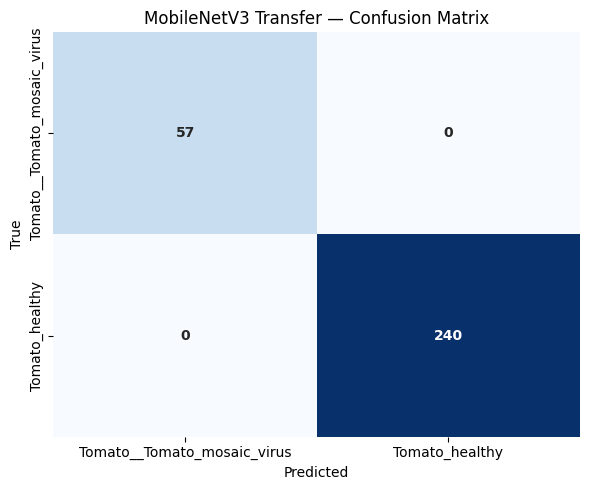

In [239]:
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV3 Transfer')

STEP 30: Fine-Tuning

In [240]:
# Unfreeze the top 30 layers of the base model
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

Trainable base layers after unfreezing: 30 / 157


In [241]:
probs = tl_model.predict(test_dataset)
print(probs.min())
print(probs.max())
print(probs.mean())
print(probs[:20].flatten())

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step
8.942978e-07
0.99999905
0.5
[0.98906136 0.01093865 0.9936459  0.00635412 0.9538193  0.04618075
 0.9937767  0.00622333 0.98520017 0.01479984 0.7899772  0.21002288
 0.7966449  0.2033551  0.9966317  0.00336833 0.72868127 0.27131873
 0.9980069  0.00199312 0.945207   0.054793   0.9989497  0.00105034
 0.9964064  0.00359363 0.9861979  0.01380217 0.74866337 0.2513366
 0.9989975  0.00100251 0.72074765 0.27925238 0.9942437  0.00575634
 0.9465274  0.05347253 0.95263946 0.04736048]


Save Model


In [243]:
tl_model.save('models/mobilenetv3_final.keras')
print("Saved successfully!")

Saved successfully!


In [244]:
import os
print(os.listdir('models'))

['tl_feature_extraction_best.keras', 'custom_cnn_v2_best.keras', 'mobilenetv3_final.keras']


STEP 34: Evaluate the fine-tuned model on the test set.

2026-07-29 01:12:49.390899: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



MobileNetV3 Fine-Tuned
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000

Classification Report:
                             precision    recall  f1-score   support

Tomato__Tomato_mosaic_virus     1.0000    1.0000    1.0000        57
             Tomato_healthy     1.0000    1.0000    1.0000       240

                   accuracy                         1.0000       297
                  macro avg     1.0000    1.0000    1.0000       297
               weighted avg     1.0000    1.0000    1.0000       297



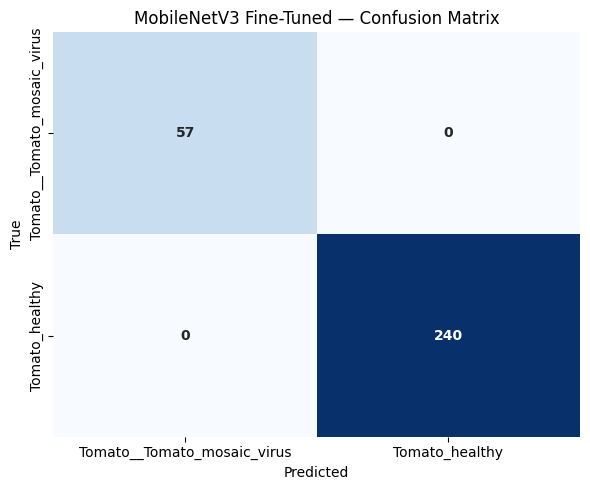

In [245]:
ft_test_acc = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV3 Fine-Tuned')

STEP 37: Predict on a new image. Load any .jpg image plant image from disk, resize it to 224×224,

In [ ]:
def predict_image(img_path, models_dict, class_names, image_size=(224, 224)):
    """Load an image file and classify it with each model in models_dict."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    # [0, 255] float32
    img_array = np.expand_dims(img_array, axis=0)
    # (1, H, W, 3)
    
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()
    
    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        prob = mdl.predict(img_array, verbose=0)[0][0]
        label = class_names[int(prob >= 0.5)]
        print(f'{name:<25}: {label} (p={prob:.4f})')

STEP 38: Uncomment the predict_image() call below and supply a real image path to test.

In [ ]:

# Update path to an image you want to test
predict_image(
    'path/to/your/image.jpg',
    {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},
    class_names
)